# BCV Pseudo-R² vs n_components — Reaching

Load pre-computed BCV scores from `results/sweep-n_component/` and plot
pseudo-R² as a function of `n_components` for:
- **nonlinear-nonlinear** (MLP decoder, Poisson loss)
- **nonlinear-linear** (Poisson GLM decoder)

In [6]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

## Config

In [7]:
SWEEP_ROOT   = "./results/sweep-n_component/r2"
N_COMPONENTS = [6, 10, 16, 20, 30, 40]

CONDITIONS = {
    "nonlinear-nonlinear": {"color": "#2196F3", "label": "nonlinear-nonlinear\n(MLP, Poisson loss)"},
    "nonlinear-linear":    {"color": "#FF9800", "label": "nonlinear-linear\n(Poisson GLM)"},
}

## 1. Load BCV scores

Each `bcv_summary.pt` is a dict mapping `n_components → [fold_0_score, ..., fold_4_score]`.

In [8]:
scores = {}

for cond in CONDITIONS:
    summary_path = os.path.join(SWEEP_ROOT, cond, "bcv_summary.pt")
    if not os.path.exists(summary_path):
        # Fall back to loading per-n_components files
        summary = {}
        for K in N_COMPONENTS:
            p = os.path.join(SWEEP_ROOT, cond, f"n_components_{K}", "bcv_scores.pt")
            if os.path.exists(p):
                summary[K] = torch.load(p, weights_only=False)
        scores[cond] = summary
    else:
        scores[cond] = torch.load(summary_path, weights_only=False)

for cond, summary in scores.items():
    print(f"{cond}:")
    for K in sorted(summary):
        vals = summary[K]
        print(f"  n_components={K:2d}: mean={np.mean(vals):.4f} ± {np.std(vals):.4f}  folds={[f'{v:.4f}' for v in vals]}")

nonlinear-nonlinear:
  n_components= 6: mean=0.0568 ± 0.0068  folds=['0.0567', '0.0565', '0.0489', '0.0528', '0.0692']
  n_components=10: mean=0.0593 ± 0.0056  folds=['0.0622', '0.0572', '0.0529', '0.0554', '0.0687']
  n_components=16: mean=0.0617 ± 0.0051  folds=['0.0640', '0.0617', '0.0581', '0.0548', '0.0699']
  n_components=20: mean=0.0606 ± 0.0072  folds=['0.0634', '0.0601', '0.0577', '0.0499', '0.0719']
  n_components=30: mean=0.0602 ± 0.0057  folds=['0.0624', '0.0599', '0.0565', '0.0528', '0.0695']
  n_components=40: mean=0.0595 ± 0.0062  folds=['0.0613', '0.0572', '0.0547', '0.0536', '0.0707']
nonlinear-linear:
  n_components= 6: mean=0.0007 ± 0.0004  folds=['0.0004', '0.0010', '0.0013', '0.0002', '0.0005']
  n_components=10: mean=0.0011 ± 0.0003  folds=['0.0012', '0.0006', '0.0014', '0.0015', '0.0009']
  n_components=16: mean=0.0008 ± 0.0003  folds=['0.0005', '0.0007', '0.0007', '0.0008', '0.0014']
  n_components=20: mean=0.0271 ± 0.0080  folds=['0.0318', '0.0117', '0.0266', '

## 2. Plot pseudo-R² vs n_components

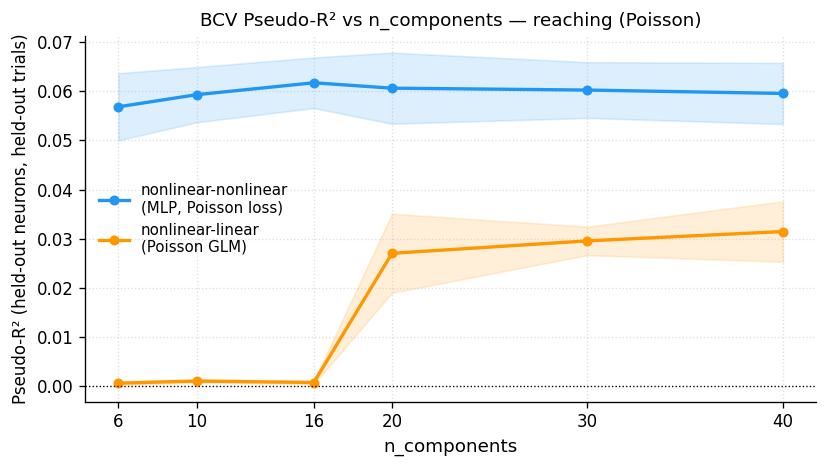

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))

for cond, meta in CONDITIONS.items():
    summary = scores.get(cond, {})
    Ks      = sorted(summary.keys())
    if not Ks:
        print(f"No data for {cond}, skipping.")
        continue

    means = np.array([np.mean(summary[K]) for K in Ks])
    stds  = np.array([np.std(summary[K])  for K in Ks])

    ax.plot(Ks, means, color=meta["color"], lw=2, marker="o", ms=5, label=meta["label"])
    ax.fill_between(Ks, means - stds, means + stds, color=meta["color"], alpha=0.15)

ax.set_xlabel("n_components", fontsize=11)
ax.set_ylabel("Pseudo-R² (held-out neurons, held-out trials)", fontsize=10)
ax.set_title("BCV Pseudo-R² vs n_components — reaching (Poisson)", fontsize=11)
ax.set_xticks(N_COMPONENTS)
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(ls=":", alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(SWEEP_ROOT, "R2_vs_ncomponents.pdf"), bbox_inches="tight")
plt.show()